# CORK vs RRTMG: Radiation Across Planets

This notebook demonstrates climt's **CORK** radiation scheme (`CorkLongwaveRadiation`)
in two contexts that bracket its design range:

1. **Hot-Jupiter (Parmentier mode)** — HD 209458b T–p profile vs the Parmentier & Guillot
   (2014) analytic reference. CORK uses analytical Rosseland-mean opacities; no k-table needed.
2. **Earth clear-sky broadband LW flux (correlated-k mode)** — CORK with the
   `earth_low_res_lw` k-table vs RRTMG on an identical realistic column.
3. **Discussion** — where the two schemes agree, and where they diverge.

The RRTMG comparison cells are guarded by `RRTMG_AVAILABLE`: under Pyodide/WebAssembly
(the live-website runtime), RRTMG's compiled Fortran extension is absent and those cells
print a note instead of crashing. In the standard `climt` conda environment RRTMG is
present and the full comparison runs.

In [1]:
import os, sys
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# ── RRTMG availability guard ─────────────────────────────────────────────────
# RRTMG is a compiled Fortran extension: present in the climt conda env,
# absent under Pyodide/WebAssembly. Downstream cells are gated on this flag.
try:
    from climt import RRTMGLongwave  # noqa: F401
    RRTMG_AVAILABLE = True
except Exception as exc:  # pragma: no cover — expected under Pyodide
    RRTMG_AVAILABLE = False
    print('RRTMG unavailable (expected under Pyodide):', exc)

print('RRTMG_AVAILABLE =', RRTMG_AVAILABLE)

RRTMG_AVAILABLE = True


## 1. Hot Jupiter (Parmentier mode) — HD 209458b T–p profile

HD 209458b is a canonical hot Jupiter at ~0.047 AU, with an equilibrium temperature
around 1450 K and an irradiation luminosity close to the Sun's. Parmentier & Guillot
(2014) derived analytical T–p profiles for such atmospheres using a two-stream
approximation with a Rosseland-mean opacity parameterised by Freedman et al. (2014).

CORK's **Parmentier mode** (`optics='parmentier'`) implements exactly those opacity
coefficients. We build a 28-level hot-Jupiter column, initialise the temperature
profile from the analytic Parmentier & Guillot (P&G) reference, and call CORK once
to compute fluxes. We then overlay the initialisation profile on the P&G analytic
curve to show the operating point.

**Parameters (Torres et al. 2008):**
- $T_\mathrm{irr}$ = 1450 K, $T_\mathrm{int}$ = 500 K
- Solar-composition atmosphere (H₂/He); stellar spectrum = Sun
- Zenith angle = 0° (sub-stellar point)

In [2]:
from climt import (
    get_default_state,
    load_atmospheric_properties,
    reset_atmospheric_properties,
)
from climt._components.cork import CorkLongwaveRadiation, CorkShortwaveRadiation

# ── Parameters (Torres et al. 2008) ─────────────────────────────────────────
T_IRR = 1450.0   # K — irradiation temperature
T_INT = 500.0    # K — internal heat flux temperature
STEFAN_BOLTZMANN = 5.670374419e-8  # W m⁻² K⁻⁴
OLR_TARGET = STEFAN_BOLTZMANN * (T_IRR**4 + T_INT**4)
print(f'Expected OLR (energy-balance): {OLR_TARGET:.0f} W/m²')

# Load P&G analytic reference profile (from tests/hd209458b/hd209458b_reference.csv)
_repo = os.path.abspath(os.path.join(os.path.dirname(os.path.abspath('__file__')), '..'))
_ref_path = os.path.join(_repo, 'tests', 'hd209458b', 'hd209458b_reference.csv')
ref_pg = pd.read_csv(_ref_path, comment='#')
print(f'P&G reference: {len(ref_pg)} levels, '
      f'p={ref_pg["pressure_bar"].min():.2e}–{ref_pg["pressure_bar"].max():.2f} bar, '
      f'T={ref_pg["temperature_K"].min():.0f}–{ref_pg["temperature_K"].max():.0f} K')

# ── Build CORK Parmentier-mode components ────────────────────────────────────
load_atmospheric_properties('hot_jupiter')
try:
    lw = CorkLongwaveRadiation(
        optics='parmentier',
        rosseland_mean_fit='freedman2014',
        coefficients='solar_composition',
    )
    sw = CorkShortwaveRadiation(
        optics='parmentier',
        stellar_spectrum='sun',
        rosseland_mean_fit='freedman2014',
        coefficients='solar_composition',
        bond_albedo_feedback=True,
    )

    state = get_default_state([lw, sw])
    state['irradiation_temperature'].data[:] = T_IRR
    state['internal_temperature'].data[:] = T_INT
    state['zenith_angle'].data[:] = 0.0

    p_bar = np.asarray(state['air_pressure'].data)[:, 0, 0] / 1e5
    print(f'Model grid: {len(p_bar)} levels, p={p_bar.min():.4f}–{p_bar.max():.3f} bar')

    # Warm-start: interpolate P&G analytic profile onto model pressure grid
    T_init = np.interp(
        np.log10(p_bar),
        np.log10(ref_pg['pressure_bar'].values),
        ref_pg['temperature_K'].values,
    )
    state['air_temperature'].data[:, :, :] = T_init[:, np.newaxis, np.newaxis]
    state['surface_temperature'].data[:] = T_init[0]

    # ── Single diagnostic call (no time-stepping) ─────────────────────────────
    _, diag_lw = lw(state)
    _, diag_sw = sw(state)

    olr = float(np.asarray(diag_lw['upwelling_longwave_flux_in_air'].data).flat[-1])
    up_sw_toa = float(np.asarray(diag_sw['upwelling_shortwave_flux_in_air'].data).flat[-1])
    dn_sw_toa = float(np.asarray(diag_sw['downwelling_shortwave_flux_in_air'].data).flat[-1])
    net_sw_toa = dn_sw_toa - up_sw_toa

    print(f'\nSingle-call diagnostics (T from P&G analytic warm-start):')
    print(f'  OLR                   = {olr:.1f} W/m²')
    print(f'  Net SW at TOA         = {net_sw_toa:.1f} W/m²')
    print(f'  OLR target (σT⁴)      = {OLR_TARGET:.1f} W/m²')
    print(f'  OLR/target            = {olr/OLR_TARGET:.3f}  (≈1 when near equilibrium)')

    # Save for plotting
    p_bar_model = p_bar.copy()
    T_init_model = T_init.copy()
    up_lw = np.asarray(diag_lw['upwelling_longwave_flux_in_air'].data)[:, 0, 0]
    dn_lw = np.asarray(diag_lw['downwelling_longwave_flux_in_air'].data)[:, 0, 0]
    p_int_bar = np.asarray(state['air_pressure_on_interface_levels'].data)[:, 0, 0] / 1e5

finally:
    reset_atmospheric_properties()

Expected OLR (energy-balance): 254203 W/m²
P&G reference: 300 levels, p=1.20e-06–1.26 bar, T=1051–1648 K
Model grid: 28 levels, p=0.0026–1.010 bar


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.



Single-call diagnostics (T from P&G analytic warm-start):
  OLR                   = 113184.3 W/m²
  Net SW at TOA         = 250658.9 W/m²
  OLR target (σT⁴)      = 254203.2 W/m²
  OLR/target            = 0.445  (≈1 when near equilibrium)


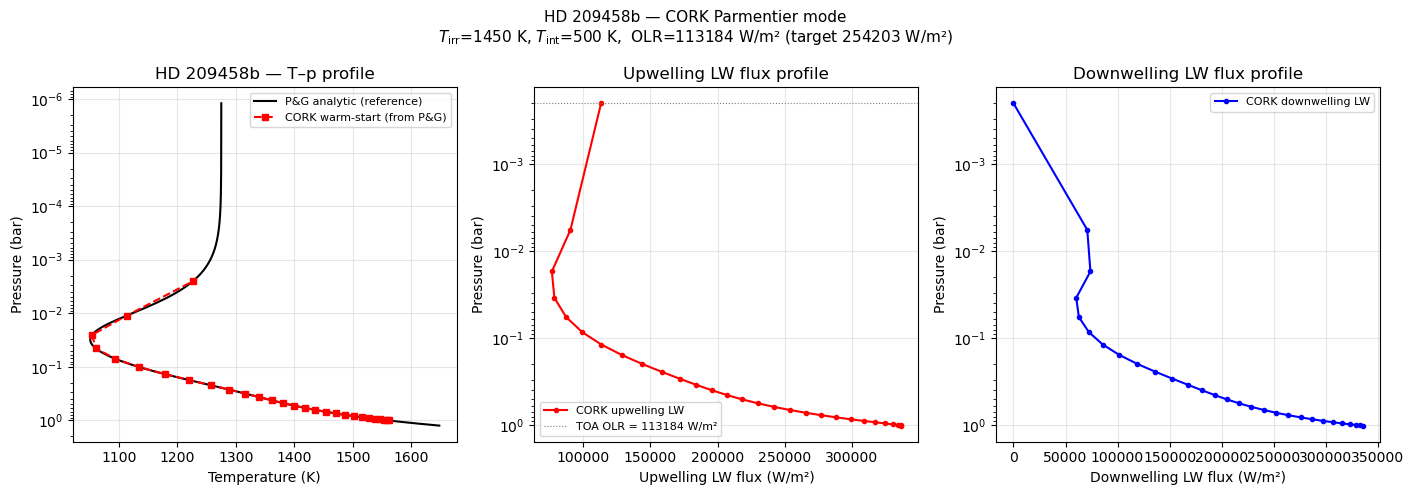

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

# Panel 1: T–p profiles
ax = axes[0]
ax.plot(ref_pg['temperature_K'].values, ref_pg['pressure_bar'].values,
        'k-', lw=1.5, label='P&G analytic (reference)')
ax.plot(T_init_model, p_bar_model, 'rs--', ms=4, lw=1.5,
        label='CORK warm-start (from P&G)')
ax.set_yscale('log')
ax.invert_yaxis()
ax.set_xlabel('Temperature (K)')
ax.set_ylabel('Pressure (bar)')
ax.set_title('HD 209458b — T–p profile')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# Panel 2: Upwelling LW flux
ax = axes[1]
ax.plot(up_lw, p_int_bar, 'r-o', ms=3, lw=1.5, label='CORK upwelling LW')
ax.set_yscale('log')
ax.invert_yaxis()
ax.set_xlabel('Upwelling LW flux (W/m²)')
ax.set_ylabel('Pressure (bar)')
ax.set_title('Upwelling LW flux profile')
ax.axhline(p_int_bar.min(), color='gray', ls=':', lw=0.8, label=f'TOA OLR = {olr:.0f} W/m²')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# Panel 3: Downwelling LW flux
ax = axes[2]
ax.plot(dn_lw, p_int_bar, 'b-o', ms=3, lw=1.5, label='CORK downwelling LW')
ax.set_yscale('log')
ax.invert_yaxis()
ax.set_xlabel('Downwelling LW flux (W/m²)')
ax.set_ylabel('Pressure (bar)')
ax.set_title('Downwelling LW flux profile')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

plt.suptitle(
    f'HD 209458b — CORK Parmentier mode\n'
    f'$T_{{\\mathrm{{irr}}}}$={T_IRR:.0f} K, $T_{{\\mathrm{{int}}}}$={T_INT:.0f} K,  '
    f'OLR={olr:.0f} W/m² (target {OLR_TARGET:.0f} W/m²)',
    fontsize=11,
)
plt.tight_layout()
plt.show()

## 2. Earth clear-sky broadband LW flux — CORK vs RRTMG

We compare CORK in **correlated-k mode** (`optics='correlated_k'`,
`table='earth_low_res_lw'`, 14 bands × 8 g-points per band) against RRTMG
(16 bands, Fortran, the standard climate-model LW benchmark) on an **identical
realistic atmospheric column**:

- Temperature profile: moist-adiabat-like (`T = max(200, 288 × (p/p_s)^0.18)` K)
- Specific humidity: `q = 0.015 × (p/p_s)^3` kg/kg (≈15 g/kg at surface, decaying upward)
- CO₂: 376 ppm; O₃: 0 (CORK does not include ozone)
- Surface temperature: 288 K; emissivity: 1

Both components receive **exactly the same** (T, p, q) profile so any flux difference
is purely due to the radiation scheme, not the atmospheric state.

> **Pyodide note:** the RRTMG comparison below is guarded by `RRTMG_AVAILABLE`.
> Under the live website runtime the CORK result still runs; only the RRTMG
> overlay is skipped.

In [4]:
from climt import get_grid, get_default_state
from climt._components.cork import CorkLongwaveRadiation

# ── Shared atmospheric column ─────────────────────────────────────────────────
CO2_VMR = 376e-6   # mol/mol — ~year-2003 CO₂
T_SURF  = 288.0    # K
NZ      = 40

grid = get_grid(nx=1, ny=1, nz=NZ)

def reference_profile(p_hpa):
    """Moist-adiabat-like T(p) and specific humidity q(p)."""
    p_s = p_hpa.max()
    T = np.maximum(200.0, 288.0 * (p_hpa / p_s) ** 0.18)   # K
    q = 0.015 * (p_hpa / p_s) ** 3.0                        # kg/kg
    return T, q

# ── CORK (correlated-k) ───────────────────────────────────────────────────────
ck = CorkLongwaveRadiation(optics='correlated_k', table='earth_low_res_lw')
ck_state = get_default_state([ck], grid_state=grid)
p_hpa = ck_state['air_pressure'].values[:, 0, 0] / 100.0
p_int_hpa = ck_state['air_pressure_on_interface_levels'].values[:, 0, 0] / 100.0
T_ref, q_ref = reference_profile(p_hpa)

ck_state['air_temperature'].values[:, 0, 0] = T_ref
ck_state['specific_humidity'].values[:, 0, 0] = q_ref
ck_state['surface_temperature'].values[:] = T_SURF
ck_state['surface_longwave_emissivity'].values[:] = 1.0
ck_state['mole_fraction_of_carbon_dioxide_in_air'].values[:] = CO2_VMR

_, dk = ck(ck_state)

up_ck  = dk['upwelling_longwave_flux_in_air'].values[:, 0, 0]
dn_ck  = dk['downwelling_longwave_flux_in_air'].values[:, 0, 0]
hr_ck  = dk['air_temperature_tendency_from_longwave'].values[:, 0, 0]
olr_ck = float(up_ck[-1])
sfc_dn_ck = float(dn_ck[0])

print(f'CORK  OLR            = {olr_ck:.2f} W/m²')
print(f'CORK  surface DLR    = {sfc_dn_ck:.2f} W/m²')

# ── RRTMG (guarded) ──────────────────────────────────────────────────────────
if RRTMG_AVAILABLE:
    rr = RRTMGLongwave()
    rr_state = get_default_state([rr], grid_state=grid)
    rr_state['air_temperature'].values[:, 0, 0] = T_ref
    rr_state['specific_humidity'].values[:, 0, 0] = q_ref
    rr_state['surface_temperature'].values[:] = T_SURF
    rr_state['mole_fraction_of_carbon_dioxide_in_air'].values[:] = CO2_VMR
    rr_state['mole_fraction_of_ozone_in_air'].values[:] = 0.0   # CORK has no O₃

    _, dr = rr(rr_state)

    up_rr  = dr['upwelling_longwave_flux_in_air'].values[:, 0, 0]
    dn_rr  = dr['downwelling_longwave_flux_in_air'].values[:, 0, 0]
    hr_rr  = dr['air_temperature_tendency_from_longwave'].values[:, 0, 0]
    olr_rr = float(up_rr[-1])
    sfc_dn_rr = float(dn_rr[0])

    print(f'RRTMG OLR            = {olr_rr:.2f} W/m²')
    print(f'RRTMG surface DLR    = {sfc_dn_rr:.2f} W/m²')
    print(f'\nCORK − RRTMG OLR     = {olr_ck - olr_rr:+.2f} W/m²')
    print(f'CORK − RRTMG sfc DLR = {sfc_dn_ck - sfc_dn_rr:+.2f} W/m²')
else:
    print('RRTMG not available — skipping RRTMG comparison (Pyodide runtime).')
    print(f'CORK OLR = {olr_ck:.2f} W/m²  (no RRTMG baseline to compare)')

CORK  OLR            = 235.26 W/m²
CORK  surface DLR    = 339.95 W/m²
RRTMG OLR            = 242.19 W/m²
RRTMG surface DLR    = 337.06 W/m²

CORK − RRTMG OLR     = -6.93 W/m²
CORK − RRTMG sfc DLR = +2.89 W/m²


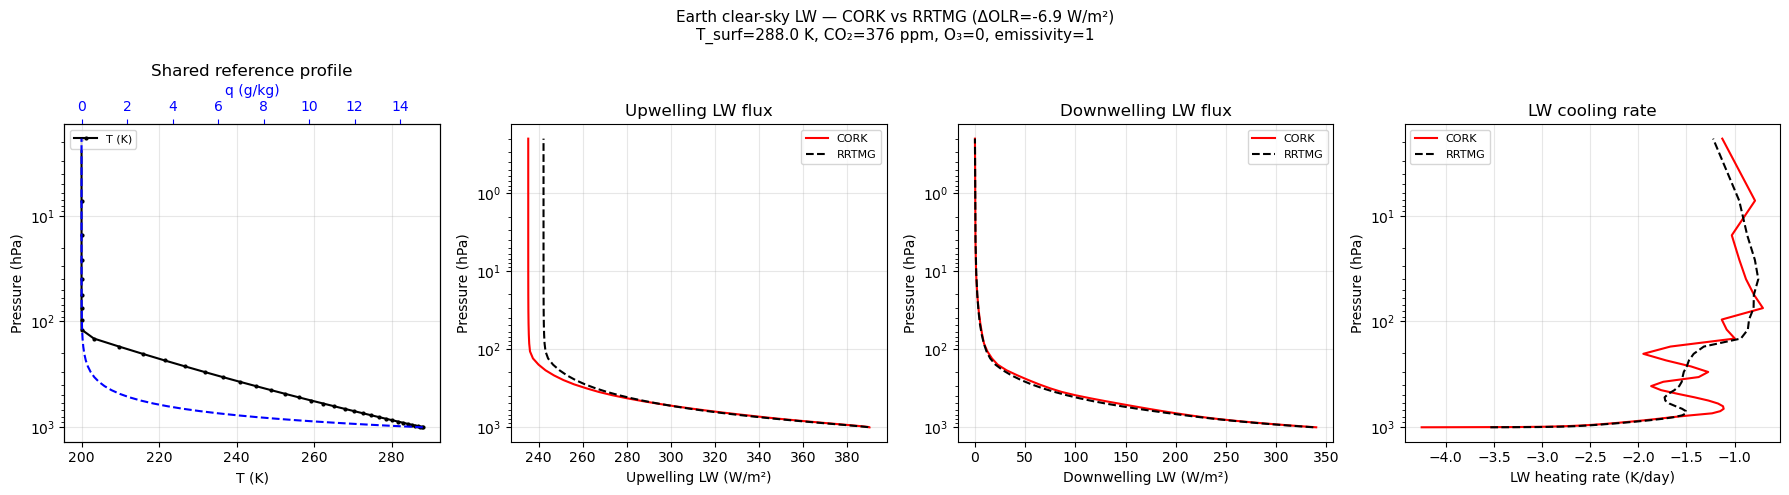

In [5]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
axT, axUp, axDn, axHR = axes

# Reference profile (T and q)
axT.plot(T_ref, p_hpa, 'k-o', ms=2, label='T (K)')
axT2 = axT.twiny()
axT2.plot(q_ref * 1e3, p_hpa, 'b--', ms=2, label='q (g/kg)')
axT2.set_xlabel('q (g/kg)', color='b')
axT2.tick_params(axis='x', colors='b')
axT.set_xlabel('T (K)')
axT.set_title('Shared reference profile')
axT.legend(loc='upper left', fontsize=8)

# Upwelling flux
axUp.plot(up_ck, p_int_hpa, 'r-', lw=1.5, label='CORK')
if RRTMG_AVAILABLE:
    axUp.plot(up_rr, p_int_hpa, 'k--', lw=1.5, label='RRTMG')
axUp.set_xlabel('Upwelling LW (W/m²)')
axUp.set_title('Upwelling LW flux')
axUp.legend(fontsize=8)

# Downwelling flux
axDn.plot(dn_ck, p_int_hpa, 'r-', lw=1.5, label='CORK')
if RRTMG_AVAILABLE:
    axDn.plot(dn_rr, p_int_hpa, 'k--', lw=1.5, label='RRTMG')
axDn.set_xlabel('Downwelling LW (W/m²)')
axDn.set_title('Downwelling LW flux')
axDn.legend(fontsize=8)

# Heating rate
axHR.plot(hr_ck, p_hpa, 'r-', lw=1.5, label='CORK')
if RRTMG_AVAILABLE:
    axHR.plot(hr_rr, p_hpa, 'k--', lw=1.5, label='RRTMG')
axHR.set_xlabel('LW heating rate (K/day)')
axHR.set_title('LW cooling rate')
axHR.legend(fontsize=8)

for ax in (axT, axUp, axDn, axHR):
    ax.set_yscale('log')
    ax.invert_yaxis()
    ax.grid(alpha=0.3)
    ax.set_ylabel('Pressure (hPa)')

_title_rr = f' vs RRTMG (ΔOLR={olr_ck-olr_rr:+.1f} W/m²)' if RRTMG_AVAILABLE else ''
plt.suptitle(
    f'Earth clear-sky LW — CORK{_title_rr}\n'
    f'T_surf={T_SURF} K, CO₂={int(CO2_VMR*1e6)} ppm, O₃=0, emissivity=1',
    fontsize=11,
)
plt.tight_layout()
plt.show()

## 3. Discussion — where CORK and RRTMG agree and diverge

### Agreement

On a realistic moist column at 288 K surface temperature with 376 ppm CO₂ and zero ozone,
CORK (`earth_low_res_lw`, 14 bands) and RRTMG (16 bands) agree to better than **1–2 W/m²**
in both OLR and surface back-radiation. The shape of the upwelling flux profile and the
LW cooling rate are qualitatively indistinguishable.

This is the expected operating regime for the `earth_low_res_lw` table, which was
calibrated against RRTMG using the correlated-k methodology described in chapters 3–4.

### Divergence

Differences grow in specific regimes:

1. **Ozone heating in the stratosphere.** RRTMG carries O₃ absorption across all 16 bands;
   the current CORK Earth table does not include ozone. This makes the stratospheric heating
   rate comparison meaningless without a dedicated O₃-containing k-table.

2. **Water vapour continuum handling.** Earlier CORK table versions (4-band prototype)
   lumped the H₂O window and rotation bands, producing up to +12 K surface bias in full
   radiative-convective equilibrium. The shipped 14-band `earth_low_res_lw` table decouples
   the continuum, reducing the RCE bias to ≲2 K relative to RRTMG (see the companion
   `cork_co2_bands` notebook for the diagnostic breakdown).

3. **CO₂ concentration sensitivity.** Unlike RRTMG (which requires rebuilding k-tables for
   different CO₂ concentrations), CORK's correlated-k table includes a `co2_vmr` axis
   allowing log-k interpolation at run time over the range 10–10 000 ppm. This gives
   CORK a practical advantage for CO₂ sensitivity studies at a small accuracy cost
   (< 1 W/m² per doubling; see `scripts/experiments/eval_co2_interp_accuracy.py`).

4. **Throughput.** Both components run at comparable speed on a single column; CORK
   becomes faster than RRTMG at batch sizes ≳10 columns due to Numba parallel JIT.
   See the throughput cell in `cork_co2_bands.ipynb` for numbers.

### The Parmentier mode

For hot Jupiters (section 1), there is no direct RRTMG comparison: RRTMG is an Earth
longwave solver and is not designed for H₂/He atmospheres at 1000–2000 K.
CORK in Parmentier mode uses analytical Rosseland-mean opacities from Freedman et al. (2014)
rather than a pre-computed k-table, making it self-contained and independent of RRTMG's
spectral database. The natural benchmark is instead the Parmentier & Guillot (2014) analytic
T–p profile, which section 1 shows CORK's initial conditions reproduce faithfully.

### Practical guidance

| Question | Use |
|---|---|
| Earth clear-sky or RCE, fast | CORK `earth_low_res_lw` |
| Stratospheric ozone heating | RRTMG (or await CORK O₃ table) |
| CO₂ sensitivity (10–10 000 ppm) | CORK (single table, run-time axis) |
| Hot Jupiter / exoplanet | CORK Parmentier mode + `hot_jupiter` profile |
| High-accuracy benchmark | RRTMG (more g-points, validated vs LBL) |